In [1]:

# CELL 1: Setup, Imports, and Configuration

import os
import sys
import glob
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from scipy import ndimage
from scipy.stats import entropy
from skimage.feature import graycomatrix, graycoprops

from sklearn.model_selection import (
    StratifiedKFold,
    RepeatedStratifiedKFold,
    StratifiedGroupKFold
)
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models

# -----------------------------
# Reproducibility
# -----------------------------
warnings.filterwarnings("default")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# -----------------------------
# Google Drive Configuration
# -----------------------------
BASE_DIR = Path("/content/drive/MyDrive")
DATA_DIR = BASE_DIR / "ThermoDataBase"

EXCEL_PATH = DATA_DIR / "Plantar Thermogram Database.xlsx"

# Keep outputs separate from the original dataset
OUTPUT_DIR = BASE_DIR / "diabetes_model_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Validate paths
# -----------------------------
print("Environment initialized.")
print("Google Drive mounted:", Path("/content/drive/MyDrive").exists())
print("Dataset directory exists:", DATA_DIR.exists())
print("Excel file exists:", EXCEL_PATH.exists())
print("Output directory:", OUTPUT_DIR)

if not DATA_DIR.is_dir():
    raise FileNotFoundError(
        f"Dataset directory not found: {DATA_DIR}\n"
        "Check the folder location in Google Drive."
    )

if not EXCEL_PATH.is_file():
    print("WARNING: Excel file not found at the configured path.")
    print("Check the exact workbook filename and location.")

print("\nDataset folders/files:")
for item in sorted(DATA_DIR.iterdir()):
    print(" -", item.name)

Environment initialized.
Google Drive mounted: True
Dataset directory exists: True
Excel file exists: True
Output directory: /content/drive/MyDrive/diabetes_model_outputs

Dataset folders/files:
 - Control Group
 - DM Group
 - Plantar Thermogram Database.xlsx
 - logo.png
 - plantar_thermogram_pipeline.ipynb


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [2]:

# CELL 2: Master Table Construction & Integrity Verification

from pathlib import Path
import pandas as pd
import warnings


def normalize_subject_id(value):
    """Convert CG001_M or CG001 to the common ID CG001."""
    if pd.isna(value):
        return None

    value = str(value).strip().upper()

    if not value:
        return None

    return value.split("_")[0]


def build_master_table(data_dir, excel_path):

    data_dir = Path(data_dir)
    excel_path = Path(excel_path)

    # --------------------------------------------------
    # 1. Validate input paths
    # --------------------------------------------------
    if not data_dir.is_dir():
        raise FileNotFoundError(
            f"Dataset directory not found: {data_dir}"
        )

    if not excel_path.is_file():
        raise FileNotFoundError(
            f"Excel workbook not found: {excel_path}"
        )

    # --------------------------------------------------
    # 2. Read Excel demographic sheets
    # --------------------------------------------------
    xls = pd.ExcelFile(excel_path)

    required_sheets = {"Control Group", "DM Group"}

    if not required_sheets.issubset(set(xls.sheet_names)):
        raise ValueError(
            f"Expected sheets {required_sheets}; "
            f"found {xls.sheet_names}"
        )

    df_c_raw = pd.read_excel(xls, sheet_name="Control Group")
    df_dm_raw = pd.read_excel(xls, sheet_name="DM Group")

    # Verify required columns
    required_columns = {"Subject", "Age (years)"}

    for sheet_name, df in [
        ("Control Group", df_c_raw),
        ("DM Group", df_dm_raw)
    ]:
        missing_columns = required_columns - set(df.columns)

        if missing_columns:
            raise ValueError(
                f"Missing columns in '{sheet_name}': "
                f"{missing_columns}"
            )

    # Assign labels based on the Excel sheet
    df_c_raw = df_c_raw.copy()
    df_dm_raw = df_dm_raw.copy()

    df_c_raw["excel_label"] = 0
    df_c_raw["excel_group"] = "Control"

    df_dm_raw["excel_label"] = 1
    df_dm_raw["excel_group"] = "DM"

    excel_all = pd.concat(
        [df_c_raw, df_dm_raw],
        ignore_index=True
    )

    excel_all["subject_key"] = (
        excel_all["Subject"].apply(normalize_subject_id)
    )

    # Missing IDs cannot be used for matching
    excel_all = excel_all.dropna(
        subset=["subject_key"]
    ).copy()

    # Prevent ambiguous demographic merges
    duplicate_ids = excel_all[
        excel_all["subject_key"].duplicated(keep=False)
    ]

    if not duplicate_ids.empty:
        raise ValueError(
            "Duplicate subject IDs found in Excel after "
            "normalization. Inspect these rows:\n"
            + duplicate_ids[
                ["Subject", "Age (years)", "excel_group"]
            ].to_string(index=False)
        )

    # --------------------------------------------------
    # 3. Locate patient folders and full-foot CSVs
    # --------------------------------------------------
    groups = [
        ("Control Group", 0),
        ("DM Group", 1)
    ]

    # Preserve the spelling shown in your directory.
    ANGIOSOME_FOLDER = "Angiosoms"

    angiosome_names = ["LCA", "LPA", "MCA", "MPA"]

    records = []

    for folder_group, label_val in groups:

        group_path = data_dir / folder_group

        if not group_path.is_dir():
            raise FileNotFoundError(
                f"Group folder not found: {group_path}"
            )

        patient_folders = sorted(
            p for p in group_path.iterdir()
            if p.is_dir()
        )

        for patient_dir in patient_folders:

            folder_name = patient_dir.name
            parts = folder_name.split("_")

            subject_id = parts[0]
            gender_folder = (
                parts[1] if len(parts) > 1 else "Unknown"
            )

            angio_dir = patient_dir / ANGIOSOME_FOLDER

            # Full-foot temperature matrices
            left_csv = patient_dir / f"{folder_name}_L.csv"
            right_csv = patient_dir / f"{folder_name}_R.csv"

            rec = {
                "subject_id": subject_id,
                "folder_name": folder_name,
                "group_dir": folder_group,
                "label": label_val,
                "gender": gender_folder,

                "left_csv": (
                    str(left_csv) if left_csv.is_file()
                    else None
                ),

                "right_csv": (
                    str(right_csv) if right_csv.is_file()
                    else None
                )
            }

            # Record all regional angiosome CSV paths
            for side in ["L", "R"]:
                for ang in angiosome_names:

                    ang_csv = (
                        angio_dir /
                        f"{folder_name}_{side}_{ang}.csv"
                    )

                    col_name = f"{side}_{ang}_csv"

                    rec[col_name] = (
                        str(ang_csv) if ang_csv.is_file()
                        else None
                    )

            records.append(rec)

    if not records:
        raise ValueError(
            "No patient folders were found. "
            "Check the dataset directory structure."
        )

    df_files = pd.DataFrame(records)

    # --------------------------------------------------
    # 4. Check duplicate patient IDs across folders
    # --------------------------------------------------
    duplicate_patients = df_files[
        df_files["subject_id"].duplicated(keep=False)
    ]

    if not duplicate_patients.empty:
        raise ValueError(
            "Duplicate subject IDs found in patient folders:\n"
            + duplicate_patients[
                ["subject_id", "folder_name", "group_dir"]
            ].to_string(index=False)
        )

    # --------------------------------------------------
    # 5. Merge Excel demographics with patient records
    # --------------------------------------------------
    df_files["subject_key"] = (
        df_files["subject_id"].apply(normalize_subject_id)
    )

    excel_meta = excel_all[
        [
            "subject_key",
            "Subject",
            "Age (years)",
            "excel_label",
            "excel_group"
        ]
    ].rename(
        columns={"Age (years)": "age"}
    )

    merged = df_files.merge(
        excel_meta,
        on="subject_key",
        how="left",
        validate="one_to_one",
        indicator=True
    )

    # Report patients without a matching Excel record
    unmatched = merged[merged["_merge"] == "left_only"]

    if not unmatched.empty:
        print("\nWARNING: Subjects missing from Excel metadata:")
        print(
            unmatched[
                ["subject_id", "folder_name", "group_dir"]
            ].to_string(index=False)
        )

    # Check that matched Excel labels agree with folder labels
    matched = merged[merged["_merge"] == "both"]

    label_mismatch = matched[
        matched["label"] != matched["excel_label"]
    ]

    if not label_mismatch.empty:
        raise ValueError(
            "Folder labels and Excel labels disagree:\n"
            + label_mismatch[
                ["subject_id", "group_dir", "label", "excel_label"]
            ].to_string(index=False)
        )

    merged = merged.drop(columns=["_merge"])

    # --------------------------------------------------
    # 6. Verify full-foot CSV integrity
    # --------------------------------------------------
    missing_left = merged[merged["left_csv"].isna()]
    missing_right = merged[merged["right_csv"].isna()]

    print("\n========== DATASET INTEGRITY REPORT ==========")

    print(f"Total patient folders: {len(merged)}")

    print(
        f"Controls: {(merged['label'] == 0).sum()}"
    )

    print(
        f"DM subjects: {(merged['label'] == 1).sum()}"
    )

    print(f"Missing left-foot CSVs: {len(missing_left)}")
    print(f"Missing right-foot CSVs: {len(missing_right)}")

    # Report missing regional files separately
    angio_cols = [
        f"{side}_{ang}_csv"
        for side in ["L", "R"]
        for ang in angiosome_names
    ]

    print("\nMissing angiosome CSVs:")

    for col in angio_cols:
        print(f"{col}: {merged[col].isna().sum()}")

    if not missing_left.empty or not missing_right.empty:
        missing_rows = merged[
            merged["left_csv"].isna()
            | merged["right_csv"].isna()
        ]

        raise FileNotFoundError(
            "Some patients are missing full-foot CSV files:\n"
            + missing_rows[
                ["subject_id", "left_csv", "right_csv"]
            ].to_string(index=False)
        )

    if merged["age"].isna().any():
        warnings.warn(
            f"{merged['age'].isna().sum()} subjects have missing "
            "age metadata. Check Excel subject IDs."
        )

    print("\nAll patients have both full-foot CSV files.")
    print("=============================================\n")

    return merged


# --------------------------------------------------
# 7. Build the master table
# --------------------------------------------------
master_df = build_master_table(
    data_dir=DATA_DIR,
    excel_path=EXCEL_PATH
)

display(
    master_df[
        [
            "subject_id",
            "folder_name",
            "group_dir",
            "gender",
            "age",
            "label",
            "left_csv",
            "right_csv"
        ]
    ].head()
)


========== DATASET INTEGRITY REPORT ==========
Total patient folders: 167
Controls: 45
DM subjects: 122
Missing left-foot CSVs: 0
Missing right-foot CSVs: 0

Missing angiosome CSVs:
L_LCA_csv: 0
L_LPA_csv: 0
L_MCA_csv: 0
L_MPA_csv: 0
R_LCA_csv: 0
R_LPA_csv: 0
R_MCA_csv: 0
R_MPA_csv: 0

All patients have both full-foot CSV files.



/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,subject_id,folder_name,group_dir,gender,age,label,left_csv,right_csv
0,CG001,CG001_M,Control Group,M,25.0,0,/content/drive/MyDrive/ThermoDataBase/Control ...,/content/drive/MyDrive/ThermoDataBase/Control ...
1,CG002,CG002_M,Control Group,M,26.0,0,/content/drive/MyDrive/ThermoDataBase/Control ...,/content/drive/MyDrive/ThermoDataBase/Control ...
2,CG003,CG003_M,Control Group,M,24.0,0,/content/drive/MyDrive/ThermoDataBase/Control ...,/content/drive/MyDrive/ThermoDataBase/Control ...
3,CG004,CG004_F,Control Group,F,22.0,0,/content/drive/MyDrive/ThermoDataBase/Control ...,/content/drive/MyDrive/ThermoDataBase/Control ...
4,CG005,CG005_F,Control Group,F,38.0,0,/content/drive/MyDrive/ThermoDataBase/Control ...,/content/drive/MyDrive/ThermoDataBase/Control ...


In [3]:

# CELL 3: Image Quality Control (QC) & Defect Detection

import numpy as np
import pandas as pd
from pathlib import Path
from scipy import ndimage


def inspect_foot_matrix(csv_path):

    # --------------------------------------------------
    # 1. Initialise a consistent result structure
    # --------------------------------------------------
    result = {
        "qc_flag": "PASS",
        "qc_flags": "",
        "num_pieces": 0,
        "hole_pixels": 0,
        "hole_ratio": 0.0,
        "min_temp": np.nan,
        "max_temp": np.nan,
        "mean_temp": np.nan,
        "temp_range": np.nan,
        "implausible_count": 0,
        "implausible_ratio": 0.0,
        "invalid_pixel_count": 0,
        "mask_area": 0,
        "shape": None,
        "error": None
    }

    # --------------------------------------------------
    # 2. Check the CSV path
    # --------------------------------------------------
    if csv_path is None or pd.isna(csv_path):
        result["qc_flag"] = "MISSING_FILE"
        result["qc_flags"] = "MISSING_FILE"
        result["error"] = "CSV path is missing"
        return result

    csv_path = Path(csv_path)

    if not csv_path.is_file():
        result["qc_flag"] = "MISSING_FILE"
        result["qc_flags"] = "MISSING_FILE"
        result["error"] = f"File not found: {csv_path}"
        return result

    # --------------------------------------------------
    # 3. Read numeric temperature matrix
    # --------------------------------------------------
    try:
        df = pd.read_csv(csv_path, header=None)

        # Convert nonnumeric entries to NaN for detection.
        numeric_df = df.apply(pd.to_numeric, errors="coerce")
        mat = numeric_df.to_numpy(dtype=np.float32)

    except Exception as e:
        result["qc_flag"] = "READ_ERROR"
        result["qc_flags"] = "READ_ERROR"
        result["error"] = str(e)
        return result

    if mat.ndim != 2 or mat.size == 0:
        result["qc_flag"] = "EMPTY"
        result["qc_flags"] = "EMPTY"
        result["error"] = "CSV does not contain a valid 2D matrix"
        return result

    result["shape"] = str(mat.shape)

    # --------------------------------------------------
    # 4. Detect invalid numeric values
    # --------------------------------------------------
    finite_mask = np.isfinite(mat)

    invalid_count = int(np.sum(~finite_mask))
    result["invalid_pixel_count"] = invalid_count

    flags = []

    if invalid_count > 0:
        flags.append("NONFINITE_VALUES")

    # Assumption: zero/nonpositive values are background.
    # Verify this against your actual temperature CSVs.
    mask = finite_mask & (mat > 0.0)

    result["mask_area"] = int(np.sum(mask))

    if not np.any(mask):
        flags.append("EMPTY")

        result["qc_flags"] = ";".join(flags)
        result["qc_flag"] = ";".join(flags)

        return result

    # --------------------------------------------------
    # 5. Calculate temperature statistics in degrees C
    # --------------------------------------------------
    foot_temps = mat[mask]

    min_temp = float(np.min(foot_temps))
    max_temp = float(np.max(foot_temps))
    mean_temp = float(np.mean(foot_temps))
    temp_range = max_temp - min_temp

    result.update({
        "min_temp": min_temp,
        "max_temp": max_temp,
        "mean_temp": mean_temp,
        "temp_range": temp_range
    })

    # --------------------------------------------------
    # 6. Detect disconnected mask components
    # --------------------------------------------------
    labeled_mask, num_features = ndimage.label(mask)

    result["num_pieces"] = int(num_features)

    if num_features > 1:
        flags.append("SPLIT_MASK")

    # --------------------------------------------------
    # 7. Detect enclosed holes
    # --------------------------------------------------
    filled_mask = ndimage.binary_fill_holes(mask)
    holes_mask = filled_mask & (~mask)

    hole_pixel_count = int(np.sum(holes_mask))

    result["hole_pixels"] = hole_pixel_count

    # Relative hole size is useful alongside the absolute count.
    hole_ratio = hole_pixel_count / max(result["mask_area"], 1)

    result["hole_ratio"] = float(hole_ratio)

    # Retain your original threshold for comparison.
    # Review this threshold after inspecting real samples.
    if hole_pixel_count > 40:
        flags.append("HOLES_PRESENT")

    # --------------------------------------------------
    # 8. Flag unusual temperatures for manual review
    # --------------------------------------------------
    # These are review thresholds, not exclusion criteria.
    implausible_mask = (foot_temps < 20.0) | (foot_temps > 36.0)

    implausible_count = int(np.sum(implausible_mask))
    implausible_ratio = implausible_count / len(foot_temps)

    result["implausible_count"] = implausible_count
    result["implausible_ratio"] = float(implausible_ratio)

    if implausible_ratio > 0.02:
        flags.append("TEMPERATURE_REVIEW")

    # --------------------------------------------------
    # 9. Detect nearly uniform temperature matrices
    # --------------------------------------------------
    if temp_range < 1.0:
        flags.append("FLAT_IMAGE")

    # --------------------------------------------------
    # 10. Return every detected flag
    # --------------------------------------------------
    result["qc_flags"] = ";".join(flags)
    result["qc_flag"] = ";".join(flags) if flags else "PASS"

    return result


# ======================================================
# Run QC for all left and right feet
# ======================================================

qc_records = []

for _, row in master_df.iterrows():

    for side in ["L", "R"]:

        csv_file = (
            row["left_csv"] if side == "L"
            else row["right_csv"]
        )

        qc = inspect_foot_matrix(csv_file)

        qc.update({
            "subject_id": row["subject_id"],
            "side": side,
            "folder": row["folder_name"],
            "group": row["group_dir"],
            "label": row["label"],
            "csv_path": csv_file
        })

        qc_records.append(qc)


# Convert all records to a DataFrame
qc_df = pd.DataFrame(qc_records)

# Flagged rows include all review flags and file errors.
flagged = qc_df[qc_df["qc_flag"] != "PASS"].copy()

print("========== QC SUMMARY ==========")
print(f"Total feet examined: {len(qc_df)}")
print(f"Feet passing all checks: {(qc_df['qc_flag'] == 'PASS').sum()}")
print(f"Feet flagged for review: {len(flagged)}")

print("\nQC flag counts (a foot can have multiple flags):")

flag_counts = (
    qc_df.loc[qc_df["qc_flags"] != "", "qc_flags"]
    .str.split(";")
    .explode()
    .value_counts()
)

display(flag_counts.rename("count").to_frame())

print("\nFirst 10 flagged feet:")

display(
    flagged[
        [
            "subject_id",
            "side",
            "group",
            "qc_flag",
            "num_pieces",
            "hole_pixels",
            "min_temp",
            "max_temp",
            "implausible_ratio",
            "error"
        ]
    ].head(10)
)

# Save the QC report separately from the original dataset.
qc_report_path = OUTPUT_DIR / "foot_quality_control_report.csv"
qc_df.to_csv(qc_report_path, index=False)

print("\nQC report saved to:", qc_report_path)

========== QC SUMMARY ==========
Total feet examined: 334
Feet passing all checks: 316
Feet flagged for review: 18

QC flag counts (a foot can have multiple flags):


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,count
qc_flags,
TEMPERATURE_REVIEW,16
SPLIT_MASK,2



First 10 flagged feet:


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,subject_id,side,group,qc_flag,num_pieces,hole_pixels,min_temp,max_temp,implausible_ratio,error
4,CG003,L,Control Group,SPLIT_MASK,2,0,23.952000,32.532001,0.000000,None
86,CG044,L,Control Group,TEMPERATURE_REVIEW,1,0,18.844000,25.245001,0.123333,None
87,CG044,R,Control Group,TEMPERATURE_REVIEW,1,0,19.077000,25.773001,0.105002,None
153,DM032,R,DM Group,TEMPERATURE_REVIEW,1,0,27.327000,37.278999,0.029459,None
189,DM050,R,DM Group,SPLIT_MASK,3,0,29.542999,33.875000,0.000000,None
216,DM064,L,DM Group,TEMPERATURE_REVIEW,1,0,30.542999,36.280998,0.030544,None
217,DM064,R,DM Group,TEMPERATURE_REVIEW,1,1,31.356001,36.905998,0.237829,None
218,DM065,L,DM Group,TEMPERATURE_REVIEW,1,0,18.055000,23.139000,0.357624,None
219,DM065,R,DM Group,TEMPERATURE_REVIEW,1,0,19.093000,24.660000,0.091779,None
224,DM068,L,DM Group,TEMPERATURE_REVIEW,1,0,32.516998,36.895000,0.139500,None



QC report saved to: /content/drive/MyDrive/diabetes_model_outputs/foot_quality_control_report.csv


In [4]:

# CELL 4: Conservative Defect Repair & Cleaning Gate

import numpy as np
import pandas as pd
from scipy import ndimage


def repair_foot_matrix(
    mat,
    max_hole_pixels=10,
    return_info=False
):
    """
    Conservative cleaning for a 2D foot temperature matrix.

    - Preserves disconnected components.
    - Fills only small enclosed holes.
    - Preserves unusual temperature values.
    - Reports potential local anomalies without replacing them.
    - Does not modify the original input matrix.
    """

    mat = np.asarray(mat, dtype=np.float32)

    if mat.ndim != 2 or mat.size == 0:
        raise ValueError("Expected a non-empty 2D temperature matrix.")

    clean_mat = mat.copy()

    finite_mask = np.isfinite(clean_mat)

    # Assumption: positive finite pixels represent foot temperatures.
    # Verify this against the dataset's background encoding.
    mask = finite_mask & (clean_mat > 0)

    info = {
        "invalid_pixels": int((~finite_mask).sum()),
        "components_detected": 0,
        "holes_filled": 0,
        "pixels_filled": 0,
        "potential_spikes": 0,
        "extreme_pixels_preserved": 0
    }

    if not mask.any():
        if return_info:
            return clean_mat, mask, info
        return clean_mat, mask

    # 1. Detect connected components; do not discard any.
    _, n_components = ndimage.label(mask)
    info["components_detected"] = int(n_components)

    # 2. Identify enclosed holes.
    filled_mask = ndimage.binary_fill_holes(mask)
    holes = filled_mask & (~mask)

    hole_labels, n_holes = ndimage.label(holes)

    for hole_id in range(1, n_holes + 1):

        hole_region = hole_labels == hole_id
        hole_size = int(hole_region.sum())

        if hole_size > max_hole_pixels:
            continue

        # Estimate temperature using valid neighbouring pixels.
        expanded = ndimage.binary_dilation(
            hole_region,
            structure=np.ones((3, 3), dtype=bool)
        )

        boundary = expanded & mask

        if not boundary.any():
            continue

        fill_value = float(np.median(clean_mat[boundary]))

        clean_mat[hole_region] = fill_value
        mask[hole_region] = True

        info["holes_filled"] += 1
        info["pixels_filled"] += hole_size

    # 3. Flag isolated local anomalies, but do not replace them.
    neighbour_count = ndimage.convolve(
        mask.astype(np.int16),
        np.ones((3, 3), dtype=np.int16),
        mode="constant",
        cval=0
    ) - mask.astype(np.int16)

    local_median = ndimage.median_filter(
        np.where(mask, clean_mat, 0.0),
        size=3,
        mode="nearest"
    )

    potential_spikes = (
        mask
        & (neighbour_count >= 5)
        & (np.abs(clean_mat - local_median) > 4.0)
    )

    info["potential_spikes"] = int(potential_spikes.sum())

    info["extreme_pixels_preserved"] = int(
        (
            mask
            & ((clean_mat < 18.0) | (clean_mat > 38.0))
        ).sum()
    )

    if return_info:
        return clean_mat, mask, info

    return clean_mat, mask


print("Cell 4 repair function defined successfully.")
print("Disconnected components and extreme temperatures are preserved.")

Cell 4 repair function defined successfully.
Disconnected components and extreme temperatures are preserved.


In [5]:

# CELL 5: Batch-Effect Diagnostic Check

from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score

batch_features = []

# Include both feet, but keep each patient's feet together during CV.
for _, row in master_df.iterrows():
    for side, col in [("L", "left_csv"), ("R", "right_csv")]:
        csv_path = row[col]

        if pd.isna(csv_path) or not Path(csv_path).is_file():
            print(f"Missing file: {csv_path}")
            continue

        mat = pd.read_csv(csv_path, header=None).to_numpy(
            dtype=np.float32
        )

        if mat.ndim != 2 or mat.size == 0:
            print(f"Invalid matrix: {csv_path}")
            continue

        valid = np.isfinite(mat) & (mat > 0)
        temps = mat[valid]

        if len(temps) == 0:
            print(f"No valid temperature pixels: {csv_path}")
            continue

        h, w = mat.shape

        batch_features.append({
            "subject_id": row["subject_id"],
            "side": side,
            "label": int(row["label"]),
            "height": h,
            "width": w,
            "aspect_ratio": h / w if w else np.nan,
            "min_temp": float(np.min(temps)),
            "max_temp": float(np.max(temps)),
            "mean_temp": float(np.mean(temps))
        })

df_batch = pd.DataFrame(batch_features).dropna()

print("Total foot matrices:", len(df_batch))
print("Unique subjects:", df_batch["subject_id"].nunique())
print("\nSubjects per group:")
print(df_batch.groupby("label")["subject_id"].nunique())

# Evaluate technical properties separately from temperature features.
feature_sets = {
    "Dimensions only": ["height", "width", "aspect_ratio"],
    "Temperature only": ["min_temp", "max_temp", "mean_temp"],
    "Dimensions + temperature": [
        "height", "width", "aspect_ratio",
        "min_temp", "max_temp", "mean_temp"
    ]
}

# Grouped CV prevents feet from the same patient entering
# both the training and test folds.
cv = StratifiedGroupKFold(
    n_splits=5, shuffle=True, random_state=42
)

y = df_batch["label"].to_numpy()
groups = df_batch["subject_id"].to_numpy()

for name, features in feature_sets.items():
    X = df_batch[features]
    fold_scores = []

    for train_idx, test_idx in cv.split(X, y, groups):
        # Each test fold must contain both classes for ROC-AUC.
        if len(np.unique(y[test_idx])) < 2:
            continue

        model = make_pipeline(
            StandardScaler(),
            LogisticRegression(
                class_weight="balanced",
                max_iter=2000,
                random_state=42
            )
        )

        model.fit(X.iloc[train_idx], y[train_idx])
        probabilities = model.predict_proba(
            X.iloc[test_idx]
        )[:, 1]

        fold_scores.append(
            roc_auc_score(y[test_idx], probabilities)
        )

    if fold_scores:
        print(
            f"{name}: mean CV AUC = {np.mean(fold_scores):.3f} "
            f"(SD = {np.std(fold_scores):.3f}, "
            f"valid folds = {len(fold_scores)})"
        )
    else:
        print(f"{name}: AUC unavailable; inspect class distribution.")

Total foot matrices: 334
Unique subjects: 167

Subjects per group:
label
0     45
1    122
Name: subject_id, dtype: int64
Dimensions only: mean CV AUC = 0.676 (SD = 0.074, valid folds = 5)


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimiz

Temperature only: mean CV AUC = 0.889 (SD = 0.030, valid folds = 5)
Dimensions + temperature: mean CV AUC = 0.898 (SD = 0.033, valid folds = 5)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are

In [6]:

# CELL 6: Geometry Standardization

import cv2
import numpy as np

def standardize_foot_geometry(
    mat,
    is_left=False,
    target_shape=(128, 64)
):
    mat = np.asarray(mat, dtype=np.float32)

    if mat.ndim != 2 or mat.size == 0:
        raise ValueError("Input must be a non-empty 2D temperature matrix.")

    target_h, target_w = target_shape
    if target_h <= 0 or target_w <= 0:
        raise ValueError("Target dimensions must be positive.")

    # Repair conservatively using Cell 4.
    clean_mat, mask = repair_foot_matrix(mat)
    clean_mat = np.asarray(clean_mat, dtype=np.float32)
    mask = np.asarray(mask, dtype=bool)

    # Invalid temperature values are not treated as valid foot pixels.
    mask &= np.isfinite(clean_mat) & (clean_mat > 0)

    if not np.any(mask):
        empty_temp = np.zeros(target_shape, dtype=np.float32)
        empty_zscore = np.zeros(target_shape, dtype=np.float32)
        return empty_temp, empty_zscore

    # Optional orientation alignment.
    # Verify this convention visually before using it for all samples.
    if is_left:
        clean_mat = np.fliplr(clean_mat)
        mask = np.fliplr(mask)

    # Crop to the bounding box of the detected foot.
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)

    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]

    cropped = clean_mat[rmin:rmax + 1, cmin:cmax + 1]
    cropped_mask = mask[rmin:rmax + 1, cmin:cmax + 1]

    ch, cw = cropped.shape

    # Aspect-ratio-preserving resize.
    scale = min(target_h / ch, target_w / cw)
    new_h = max(1, min(target_h, int(round(ch * scale))))
    new_w = max(1, min(target_w, int(round(cw * scale))))

    # Resize valid temperatures and mask weights separately.
    # This prevents background zeros from directly lowering
    # interpolated temperatures near the foot boundary.
    valid_float = cropped_mask.astype(np.float32)
    temp_values = np.where(cropped_mask, cropped, 0.0)

    numerator = cv2.resize(
        temp_values, (new_w, new_h),
        interpolation=cv2.INTER_LINEAR
    )
    weights = cv2.resize(
        valid_float, (new_w, new_h),
        interpolation=cv2.INTER_LINEAR
    )

    resized_temp = np.zeros((new_h, new_w), dtype=np.float32)
    valid_resized = cv2.resize(
        cropped_mask.astype(np.uint8),
        (new_w, new_h),
        interpolation=cv2.INTER_NEAREST
    ).astype(bool)

    valid_resized &= weights > 1e-6
    resized_temp[valid_resized] = (
        numerator[valid_resized] / weights[valid_resized]
    )

    # Place the resized foot in the center of the output canvas.
    final_temp = np.zeros(target_shape, dtype=np.float32)
    final_mask = np.zeros(target_shape, dtype=bool)

    start_y = (target_h - new_h) // 2
    start_x = (target_w - new_w) // 2

    final_temp[
        start_y:start_y + new_h,
        start_x:start_x + new_w
    ] = resized_temp

    final_mask[
        start_y:start_y + new_h,
        start_x:start_x + new_w
    ] = valid_resized

    # Within-foot Z-score representation.
    # Keep this separate from the Celsius representation.
    zscore_mat = np.zeros(target_shape, dtype=np.float32)

    foot_vals = final_temp[final_mask]

    if foot_vals.size > 0:
        mu = float(np.mean(foot_vals))
        sigma = float(np.std(foot_vals))

        if sigma > 1e-4:
            zscore_mat[final_mask] = (
                foot_vals - mu
            ) / sigma

    return final_temp, zscore_mat


print("Geometry standardization function defined.")

Geometry standardization function defined.


<frozen importlib._bootstrap>:488: ResourceWarning: unclosed file <_io.BufferedReader name='/content/drive/MyDrive/ThermoDataBase/Plantar Thermogram Database.xlsx'>


In [7]:

# CELL 6A: Synthetic test

test_mat = np.zeros((40, 25), dtype=np.float32)
test_mat[4:36, 5:21] = 32.0
test_mat[10:15, 10:15] = 34.0

temp_out, zscore_out = standardize_foot_geometry(
    test_mat,
    is_left=False,
    target_shape=(128, 64)
)

assert temp_out.shape == (128, 64)
assert zscore_out.shape == (128, 64)
assert np.all(np.isfinite(temp_out))
assert np.all(np.isfinite(zscore_out))
assert np.all(temp_out >= 0)

valid_out = temp_out > 0

assert np.any(valid_out)
assert np.isclose(temp_out[valid_out].min(), 32.0, atol=1e-3)
assert np.isclose(temp_out[valid_out].max(), 34.0, atol=1e-3)

print("Output shape:", temp_out.shape)
print("Temperature range:", temp_out[valid_out].min(),
      "to", temp_out[valid_out].max(), "°C")
print("Z-score range:", zscore_out[valid_out].min(),
      "to", zscore_out[valid_out].max())
print("All synthetic tests passed.")

Output shape: (128, 64)
Temperature range: 32.0 to 34.0 °C
Z-score range: -0.24426015 to 4.758188
All synthetic tests passed.


In [8]:

# CELL 7: Comprehensive Feature Extraction

import os
import numpy as np
import pandas as pd
from scipy.stats import entropy

# --------------------------------------------------
# 1. Thermal statistics
# --------------------------------------------------

def extract_thermal_stats(values_array, prefix=""):
    values = np.asarray(values_array, dtype=np.float32)
    values = values[np.isfinite(values)]

    if values.size == 0:
        return {
            f"{prefix}_mean": np.nan,
            f"{prefix}_std": np.nan,
            f"{prefix}_min": np.nan,
            f"{prefix}_max": np.nan,
            f"{prefix}_median": np.nan,
            f"{prefix}_p10": np.nan,
            f"{prefix}_p90": np.nan,
            f"{prefix}_range": np.nan
        }

    return {
        f"{prefix}_mean": float(np.mean(values)),
        f"{prefix}_std": float(np.std(values)),
        f"{prefix}_min": float(np.min(values)),
        f"{prefix}_max": float(np.max(values)),
        f"{prefix}_median": float(np.median(values)),
        f"{prefix}_p10": float(np.percentile(values, 10)),
        f"{prefix}_p90": float(np.percentile(values, 90)),
        f"{prefix}_range": float(np.ptp(values))
    }


# --------------------------------------------------
# 2. Mask-aware texture features
# --------------------------------------------------

def extract_glcm_features(temp_mat):
    """
    Extract horizontal, distance-1 texture features.
    Only pairs where BOTH pixels belong to the foot
    are counted.

    The 20-36 C range is used for texture quantization
    only. Original temperatures remain unchanged in
    the thermal statistics.
    """

    mat = np.asarray(temp_mat, dtype=np.float32)
    mask = np.isfinite(mat) & (mat > 0)

    if mat.ndim != 2 or not np.any(mask):
        return {
            "entropy": np.nan,
            "glcm_contrast": np.nan,
            "glcm_homogeneity": np.nan
        }

    values = mat[mask]

    # Histogram entropy from valid foot pixels.
    hist, _ = np.histogram(
        values,
        bins=np.linspace(20.0, 36.0, 17)
    )

    # Include temperatures outside 20-36 C in the
    # entropy calculation using separate overflow bins.
    below = int(np.sum(values < 20.0))
    above = int(np.sum(values > 36.0))

    hist = np.concatenate(([below], hist, [above]))
    hist = hist[hist > 0].astype(np.float64)
    probabilities = hist / hist.sum()
    ent = float(entropy(probabilities))

    # Quantize valid temperatures into 16 levels.
    # Clipping is only for this texture calculation.
    clipped = np.clip(mat, 20.0, 36.0)
    quantized = np.zeros(mat.shape, dtype=np.uint8)

    quantized[mask] = np.floor(
        (clipped[mask] - 20.0) / 16.0 * 16
    ).astype(np.uint8)

    quantized[mask] = np.clip(
        quantized[mask], 0, 15
    )

    # Horizontal neighboring pixel pairs.
    pair_mask = mask[:, :-1] & mask[:, 1:]

    if not np.any(pair_mask):
        return {
            "entropy": ent,
            "glcm_contrast": np.nan,
            "glcm_homogeneity": np.nan
        }

    left_levels = quantized[:, :-1][pair_mask].astype(int)
    right_levels = quantized[:, 1:][pair_mask].astype(int)

    glcm = np.zeros((16, 16), dtype=np.float64)
    np.add.at(glcm, (left_levels, right_levels), 1)
    np.add.at(glcm, (right_levels, left_levels), 1)

    total = glcm.sum()

    if total == 0:
        contrast = np.nan
        homogeneity = np.nan
    else:
        glcm /= total
        i, j = np.indices(glcm.shape)

        contrast = float(
            np.sum(glcm * (i - j) ** 2)
        )

        homogeneity = float(
            np.sum(glcm / (1.0 + (i - j) ** 2))
        )

    return {
        "entropy": ent,
        "glcm_contrast": contrast,
        "glcm_homogeneity": homogeneity
    }


# --------------------------------------------------
# 3. Safe temperature matrix reader
# --------------------------------------------------

def read_temperature_matrix(csv_path):
    if pd.isna(csv_path) or not os.path.isfile(str(csv_path)):
        raise FileNotFoundError(f"Missing temperature file: {csv_path}")

    mat = pd.read_csv(csv_path, header=None).to_numpy(
        dtype=np.float32
    )

    if mat.ndim != 2 or mat.size == 0:
        raise ValueError(f"Invalid temperature matrix: {csv_path}")

    return mat


def valid_temperature_pixels(mat):
    mat = np.asarray(mat, dtype=np.float32)
    return mat[np.isfinite(mat) & (mat > 0)]


# --------------------------------------------------
# 4. Extract features for one subject
# --------------------------------------------------

def extract_all_subject_features(row):
    features = {
        "subject_id": row["subject_id"],
        "label": int(row["label"]),
        "age": pd.to_numeric(row["age"], errors="coerce")
    }

    # Encode gender without silently treating unknown
    # or missing values as male.
    gender = str(row.get("gender", "")).strip().upper()

    if gender == "F":
        features["gender_code"] = 1
    elif gender == "M":
        features["gender_code"] = 0
    else:
        features["gender_code"] = np.nan

    # Full-foot temperature matrices.
    mat_l = read_temperature_matrix(row["left_csv"])
    mat_r = read_temperature_matrix(row["right_csv"])

    # Geometry-standardized matrices retain Celsius values.
    std_l, _ = standardize_foot_geometry(
        mat_l, is_left=True
    )
    std_r, _ = standardize_foot_geometry(
        mat_r, is_left=False
    )

    pixels_l = valid_temperature_pixels(std_l)
    pixels_r = valid_temperature_pixels(std_r)

    features.update(extract_thermal_stats(pixels_l, "L_foot"))
    features.update(extract_thermal_stats(pixels_r, "R_foot"))

    # Texture features.
    tex_l = extract_glcm_features(std_l)
    tex_r = extract_glcm_features(std_r)

    features.update({f"L_{k}": v for k, v in tex_l.items()})
    features.update({f"R_{k}": v for k, v in tex_r.items()})

    # Bilateral features.
    mean_l = features["L_foot_mean"]
    mean_r = features["R_foot_mean"]
    max_l = features["L_foot_max"]
    max_r = features["R_foot_max"]

    if np.isfinite(mean_l) and np.isfinite(mean_r):
        features["asym_mean_diff"] = abs(mean_l - mean_r)
        features["asym_mean_signed_diff"] = mean_l - mean_r
        features["both_feet_mean"] = (mean_l + mean_r) / 2.0

        # Avoid unstable division by a near-zero mean.
        features["asym_mean_ratio"] = (
            mean_l / mean_r if abs(mean_r) > 1e-6 else np.nan
        )
    else:
        features["asym_mean_diff"] = np.nan
        features["asym_mean_signed_diff"] = np.nan
        features["both_feet_mean"] = np.nan
        features["asym_mean_ratio"] = np.nan

    if np.isfinite(max_l) and np.isfinite(max_r):
        features["asym_max_diff"] = abs(max_l - max_r)
        features["both_feet_max"] = max(max_l, max_r)
    else:
        features["asym_max_diff"] = np.nan
        features["both_feet_max"] = np.nan

    # Angiosome regional means.
    for side in ["L", "R"]:
        for ang in ["LCA", "LPA", "MCA", "MPA"]:
            col_name = f"{side}_{ang}_csv"
            ang_path = row.get(col_name, None)
            feature_name = f"{side}_{ang}_mean"

            if pd.notna(ang_path) and os.path.isfile(str(ang_path)):
                ang_mat = read_temperature_matrix(ang_path)
                ang_pixels = valid_temperature_pixels(ang_mat)

                features[feature_name] = (
                    float(np.mean(ang_pixels))
                    if ang_pixels.size > 0
                    else np.nan
                )
            else:
                features[feature_name] = np.nan

    return features


# --------------------------------------------------
# 5. Build the subject-level feature table
# --------------------------------------------------

print("Extracting features for all subjects...")

feature_rows = []
extraction_errors = []

for _, row in master_df.iterrows():
    try:
        feature_rows.append(extract_all_subject_features(row))
    except Exception as exc:
        extraction_errors.append({
            "subject_id": row["subject_id"],
            "error": str(exc)
        })

df_features = pd.DataFrame(feature_rows)

print(
    f"Successfully extracted features for "
    f"{len(df_features)} subjects."
)
print("Feature matrix shape:", df_features.shape)

if extraction_errors:
    print("\nSubjects with extraction errors:")
    display(pd.DataFrame(extraction_errors))

print("\nClass distribution:")
print(df_features["label"].value_counts().sort_index())

print("\nMissing values in feature columns:")
print(
    df_features.drop(
        columns=["subject_id", "label"], errors="ignore"
    ).isna().sum().sort_values(ascending=False).head(15)
)

# Save a copy for reproducibility.
feature_path = OUTPUT_DIR / "subject_thermal_features.csv"
df_features.to_csv(feature_path, index=False)

print(f"\nSaved feature table to: {feature_path}")

Extracting features for all subjects...
Successfully extracted features for 167 subjects.
Feature matrix shape: (167, 40)

Class distribution:
label
0     45
1    122
Name: count, dtype: int64

Missing values in feature columns:
age              0
gender_code      0
L_foot_mean      0
L_foot_std       0
L_foot_min       0
L_foot_max       0
L_foot_median    0
L_foot_p10       0
L_foot_p90       0
L_foot_range     0
R_foot_mean      0
R_foot_std       0
R_foot_min       0
R_foot_max       0
R_foot_median    0
dtype: int64


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Saved feature table to: /content/drive/MyDrive/diabetes_model_outputs/subject_thermal_features.csv


In [9]:

# CELL 7A: Feature table validation

assert "subject_id" in df_features.columns
assert "label" in df_features.columns

assert df_features["subject_id"].is_unique, (
    "Expected one feature row per subject."
)

assert set(df_features["label"].dropna().unique()).issubset({0, 1})

print("Unique subjects:", df_features["subject_id"].nunique())
print("Duplicate subject IDs:", df_features["subject_id"].duplicated().sum())
print("Rows with missing labels:", df_features["label"].isna().sum())

feature_cols = [
    c for c in df_features.columns
    if c not in ["subject_id", "label"]
]

print("Number of predictor columns:", len(feature_cols))
print("Features containing missing values:",
      int(df_features[feature_cols].isna().any(axis=1).sum()),
      "rows have at least one missing feature.")

print("Feature table validation completed.")

Unique subjects: 167
Duplicate subject IDs: 0
Rows with missing labels: 0
Number of predictor columns: 38
Features containing missing values: 0 rows have at least one missing feature.
Feature table validation completed.


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [10]:

# CELL 8: Baseline Benchmarks
# Age-only vs Thermal-only vs Thermal + Age

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, balanced_accuracy_score

# ---------------------------------------------
# 1. Prepare data
# ---------------------------------------------

df_eval = df_features.copy()

# Ensure labels are valid.
df_eval = df_eval[df_eval["label"].isin([0, 1])].reset_index(drop=True)

y = df_eval["label"].astype(int).to_numpy()
groups = df_eval["subject_id"].astype(str).to_numpy()

# Age-only predictor.
age_cols = ["age"]

# Thermal features exclude identifiers, labels, and demographics.
excluded_cols = {"subject_id", "label", "age", "gender_code"}
thermal_cols = [
    c for c in df_eval.columns
    if c not in excluded_cols
]

# Convert predictors to numeric; treat infinity as missing.
X_age = (
    df_eval[age_cols]
    .apply(pd.to_numeric, errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
)

X_thermal = (
    df_eval[thermal_cols]
    .apply(pd.to_numeric, errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
)

X_combined = pd.concat(
    [X_thermal, X_age],
    axis=1
)

print("Subjects:", len(df_eval))
print("Unique subject IDs:", pd.Series(groups).nunique())
print("Thermal feature count:", len(thermal_cols))
print("Class counts:")
print(pd.Series(y).value_counts().sort_index())

# ---------------------------------------------
# 2. Define baseline models
# ---------------------------------------------

model_inputs = {
    "Age Only": X_age,
    "Thermal Only": X_thermal,
    "Thermal + Age": X_combined
}

# ---------------------------------------------
# 3. Repeated patient-level cross-validation
# ---------------------------------------------

all_results = []

# Repeat grouped 5-fold CV with five different seeds.
# Since each row represents one subject, groups prevent
# the same subject appearing in train and test sets.
for repeat_seed in range(5):
    cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=42 + repeat_seed
    )

    for fold, (train_idx, test_idx) in enumerate(
        cv.split(X_age, y, groups), start=1
    ):
        y_train = y[train_idx]
        y_test = y[test_idx]

        if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
            print(f"Skipping repeat {repeat_seed + 1}, fold {fold}: "
                  "a partition contains only one class.")
            continue

        for model_name, X in model_inputs.items():
            X_train = X.iloc[train_idx]
            X_test = X.iloc[test_idx]

            model = make_pipeline(
                SimpleImputer(strategy="median"),
                StandardScaler(),
                LogisticRegression(
                    class_weight="balanced",
                    max_iter=3000,
                    random_state=42
                )
            )

            model.fit(X_train, y_train)

            probabilities = model.predict_proba(X_test)[:, 1]
            predictions = model.predict(X_test)

            all_results.append({
                "model": model_name,
                "repeat": repeat_seed + 1,
                "fold": fold,
                "auc": roc_auc_score(y_test, probabilities),
                "balanced_accuracy": balanced_accuracy_score(
                    y_test, predictions
                )
            })

# ---------------------------------------------
# 4. Summarize results
# ---------------------------------------------

results_df = pd.DataFrame(all_results)

summary = (
    results_df.groupby("model")
    .agg(
        mean_auc=("auc", "mean"),
        sd_auc=("auc", "std"),
        mean_balanced_accuracy=("balanced_accuracy", "mean"),
        sd_balanced_accuracy=("balanced_accuracy", "std"),
        evaluated_folds=("auc", "count")
    )
    .reindex(["Age Only", "Thermal Only", "Thermal + Age"])
)

print("\n" + "=" * 75)
print("BASELINE BENCHMARKS — REPEATED STRATIFIED GROUPED 5-FOLD CV")
print("=" * 75)

for model_name, row in summary.iterrows():
    print(
        f"{model_name:18s} | "
        f"AUC = {row['mean_auc']:.3f} ± {row['sd_auc']:.3f} | "
        f"Balanced Accuracy = "
        f"{row['mean_balanced_accuracy']:.3f} ± "
        f"{row['sd_balanced_accuracy']:.3f} | "
        f"Folds = {int(row['evaluated_folds'])}"
    )

print("=" * 75)

Subjects: 167
Unique subject IDs: 167
Thermal feature count: 36
Class counts:
0     45
1    122
Name: count, dtype: int64


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: date


BASELINE BENCHMARKS — REPEATED STRATIFIED GROUPED 5-FOLD CV
Age Only           | AUC = 0.969 ± 0.031 | Balanced Accuracy = 0.919 ± 0.062 | Folds = 25
Thermal Only       | AUC = 0.942 ± 0.040 | Balanced Accuracy = 0.889 ± 0.070 | Folds = 25
Thermal + Age      | AUC = 0.979 ± 0.025 | Balanced Accuracy = 0.912 ± 0.055 | Folds = 25


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are

In [11]:

# CELL 9: Classical ML Model Comparison
# Patient-level CV + in-fold imputation, scaling, feature selection

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    roc_auc_score,
    balanced_accuracy_score,
    confusion_matrix
)

# ---------------------------------------------
# 1. Prepare data
# ---------------------------------------------

df_eval = df_features.copy()
df_eval = df_eval[df_eval["label"].isin([0, 1])].reset_index(drop=True)

y = df_eval["label"].astype(int).to_numpy()
groups = df_eval["subject_id"].astype(str).to_numpy()

excluded_cols = {"subject_id", "label", "age", "gender_code"}
thermal_cols = [
    c for c in df_eval.columns
    if c not in excluded_cols
]

X_therm = (
    df_eval[thermal_cols]
    .apply(pd.to_numeric, errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
)

# Remove features that are entirely missing in the dataset.
thermal_cols = X_therm.columns[X_therm.notna().any()].tolist()
X_therm = X_therm[thermal_cols]

print("Subjects:", len(df_eval))
print("Unique patients:", pd.Series(groups).nunique())
print("Thermal features available:", len(thermal_cols))

# ---------------------------------------------
# 2. Define candidate models
# ---------------------------------------------

model_templates = {
    "Logistic Regression (L1)": LogisticRegression(
        penalty="l1",
        solver="liblinear",
        class_weight="balanced",
        C=0.5,
        max_iter=3000,
        random_state=42
    ),

    "SVM (RBF Kernel)": SVC(
        kernel="rbf",
        probability=True,
        class_weight="balanced",
        C=1.0,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=4,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=80,
        max_depth=3,
        learning_rate=0.05,
        random_state=42
    )
}

# ---------------------------------------------
# 3. Repeated patient-level cross-validation
# ---------------------------------------------

results_table = []

for m_name, model_template in model_templates.items():

    fold_aucs = []
    fold_bacc = []
    fold_sens = []
    fold_spec = []

    for repeat in range(5):
        cv = StratifiedGroupKFold(
            n_splits=5,
            shuffle=True,
            random_state=42 + repeat
        )

        for fold, (train_idx, test_idx) in enumerate(
            cv.split(X_therm, y, groups), start=1
        ):
            X_tr = X_therm.iloc[train_idx].copy()
            X_te = X_therm.iloc[test_idx].copy()

            y_tr = y[train_idx]
            y_te = y[test_idx]

            # Both classes must exist in the test fold for AUC.
            if len(np.unique(y_tr)) < 2 or len(np.unique(y_te)) < 2:
                print(f"Skipping repeat {repeat + 1}, fold {fold}: "
                      "one class missing.")
                continue

            # Remove features that are completely missing in
            # this training fold; do not inspect test values.
            usable_cols = X_tr.columns[X_tr.notna().any()].tolist()

            if not usable_cols:
                print(f"Skipping repeat {repeat + 1}, fold {fold}: "
                      "no usable training features.")
                continue

            X_tr = X_tr[usable_cols]
            X_te = X_te[usable_cols]

            # Fit imputation using training data only.
            imputer = SimpleImputer(strategy="median")
            X_tr_imp = imputer.fit_transform(X_tr)
            X_te_imp = imputer.transform(X_te)

            # Fit scaling using training data only.
            scaler = RobustScaler()
            X_tr_sc = scaler.fit_transform(X_tr_imp)
            X_te_sc = scaler.transform(X_te_imp)

            # Feature selection is fitted only on the training fold.
            k = min(12, X_tr_sc.shape[1])

            selector = SelectKBest(
                score_func=lambda X, target: mutual_info_classif(
                    X, target, random_state=42
                ),
                k=k
            )

            X_tr_sel = selector.fit_transform(X_tr_sc, y_tr)
            X_te_sel = selector.transform(X_te_sc)

            # Fresh model instance for every fold.
            model = clone(model_template)
            model.fit(X_tr_sel, y_tr)

            probs = model.predict_proba(X_te_sel)[:, 1]
            preds = (probs >= 0.5).astype(int)

            tn, fp, fn, tp = confusion_matrix(
                y_te, preds, labels=[0, 1]
            ).ravel()

            sens = tp / (tp + fn) if (tp + fn) else np.nan
            spec = tn / (tn + fp) if (tn + fp) else np.nan

            fold_aucs.append(roc_auc_score(y_te, probs))
            fold_bacc.append(balanced_accuracy_score(y_te, preds))
            fold_sens.append(sens)
            fold_spec.append(spec)

    results_table.append({
        "Model": m_name,
        "AUC Mean": np.mean(fold_aucs) if fold_aucs else np.nan,
        "AUC Std": np.std(fold_aucs, ddof=1) if len(fold_aucs) > 1 else np.nan,
        "Balanced Acc": np.mean(fold_bacc) if fold_bacc else np.nan,
        "Sensitivity": np.nanmean(fold_sens) if fold_sens else np.nan,
        "Specificity": np.nanmean(fold_spec) if fold_spec else np.nan,
        "Valid Folds": len(fold_aucs)
    })

df_model_comparison = (
    pd.DataFrame(results_table)
    .sort_values("AUC Mean", ascending=False, na_position="last")
    .reset_index(drop=True)
)

display(df_model_comparison)

Subjects: 167
Unique patients: 167
Thermal features available: 36


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,Model,AUC Mean,AUC Std,Balanced Acc,Sensitivity,Specificity,Valid Folds
0,SVM (RBF Kernel),0.909652,0.051115,0.791000,0.875333,0.706667,25
1,Random Forest,0.896433,0.052977,0.825989,0.847533,0.804444,25
2,Logistic Regression (L1),0.893407,0.047091,0.843122,0.788467,0.897778,25
3,Gradient Boosting,0.863900,0.058479,0.764256,0.857400,0.671111,25


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:

# CELL 10: Confound Ablation Matrix

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, balanced_accuracy_score

# --------------------------------------------------
# 1. Prepare subject-level data
# --------------------------------------------------

df_eval = df_features.copy()
df_eval = df_eval[df_eval["label"].isin([0, 1])].reset_index(drop=True)

assert df_eval["subject_id"].is_unique, (
    "Expected one row per subject. Check Cell 7 first."
)

demographic_cols = ["age", "gender_code"]

excluded_cols = {
    "subject_id", "label", "age", "gender_code"
}

thermal_cols = [
    c for c in df_eval.columns
    if c not in excluded_cols
]

# Ensure predictors are numeric; treat invalid values as missing.
for col in thermal_cols + demographic_cols:
    df_eval[col] = pd.to_numeric(
        df_eval[col], errors="coerce"
    )
    df_eval[col] = df_eval[col].replace(
        [np.inf, -np.inf], np.nan
    )

# Drop features that have no usable values in the full dataset.
thermal_cols = [
    c for c in thermal_cols
    if df_eval[c].notna().any()
]

demographic_cols = [
    c for c in demographic_cols
    if df_eval[c].notna().any()
]

# --------------------------------------------------
# 2. Evaluation function
# --------------------------------------------------

def evaluate_grouped_subset(data, feature_cols, n_splits=5, n_repeats=5):
    """
    Repeated grouped CV.
    Imputation and scaling are fitted on training folds only.
    """

    X = data[feature_cols].copy()
    y_local = data["label"].astype(int).to_numpy()
    groups_local = data["subject_id"].astype(str).to_numpy()

    class_counts = pd.Series(y_local).value_counts()

    # Need enough independent subjects in each class for 5 folds.
    if len(class_counts) < 2 or class_counts.min() < n_splits:
        return np.nan, np.nan, np.nan

    aucs = []
    baccs = []

    for repeat in range(n_repeats):
        cv = StratifiedGroupKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=42 + repeat
        )

        for train_idx, test_idx in cv.split(
            X, y_local, groups_local
        ):
            X_train = X.iloc[train_idx]
            X_test = X.iloc[test_idx]
            y_train = y_local[train_idx]
            y_test = y_local[test_idx]

            if len(np.unique(y_train)) < 2:
                continue

            if len(np.unique(y_test)) < 2:
                continue

            # Remove features entirely missing in this training fold.
            usable_cols = X_train.columns[
                X_train.notna().any()
            ].tolist()

            if not usable_cols:
                continue

            X_train = X_train[usable_cols]
            X_test = X_test[usable_cols]

            model = make_pipeline(
                SimpleImputer(strategy="median"),
                StandardScaler(),
                LogisticRegression(
                    class_weight="balanced",
                    max_iter=3000,
                    random_state=42
                )
            )

            model.fit(X_train, y_train)

            probabilities = model.predict_proba(X_test)[:, 1]
            predictions = model.predict(X_test)

            aucs.append(roc_auc_score(y_test, probabilities))
            baccs.append(
                balanced_accuracy_score(y_test, predictions)
            )

    if not aucs:
        return np.nan, np.nan, np.nan

    return (
        float(np.mean(aucs)),
        float(np.std(aucs, ddof=1)) if len(aucs) > 1 else np.nan,
        float(np.mean(baccs))
    )


# --------------------------------------------------
# 3. Conditions 1-3: Full cohort
# --------------------------------------------------

auc_1, std_1, bacc_1 = evaluate_grouped_subset(
    df_eval, thermal_cols
)

auc_2, std_2, bacc_2 = evaluate_grouped_subset(
    df_eval, thermal_cols + demographic_cols
)

auc_3, std_3, bacc_3 = evaluate_grouped_subset(
    df_eval, demographic_cols
)


# --------------------------------------------------
# 4. Condition 4: Age-restricted cohort (35-60)
# --------------------------------------------------

age_mask = df_eval["age"].between(35, 60, inclusive="both")
df_matched = df_eval.loc[age_mask].copy().reset_index(drop=True)

counts = df_matched["label"].value_counts()

n_controls = int(counts.get(0, 0))
n_dm = int(counts.get(1, 0))

print(
    f"Age-restricted cohort (35-60 years): {len(df_matched)} subjects "
    f"({n_controls} Controls, {n_dm} DM)"
)

if n_controls >= 5 and n_dm >= 5:
    auc_4, std_4, bacc_4 = evaluate_grouped_subset(
        df_matched, thermal_cols
    )
else:
    auc_4, std_4, bacc_4 = np.nan, np.nan, np.nan
    print(
        "Not enough subjects in one or both classes "
        "for five-fold grouped validation."
    )


# --------------------------------------------------
# 5. Display the ablation matrix
# --------------------------------------------------

def format_auc(mean, std):
    if pd.isna(mean):
        return "Not available"
    if pd.isna(std):
        return f"{mean:.3f} ± NA"
    return f"{mean:.3f} ± {std:.3f}"


ablation_df = pd.DataFrame([
    {
        "Condition": "(1) Thermal Features Only",
        "Subjects": len(df_eval),
        "AUC": format_auc(auc_1, std_1),
        "Balanced Accuracy": bacc_1
    },
    {
        "Condition": "(2) Thermal + Age + Gender",
        "Subjects": len(df_eval),
        "AUC": format_auc(auc_2, std_2),
        "Balanced Accuracy": bacc_2
    },
    {
        "Condition": "(3) Age + Gender Only",
        "Subjects": len(df_eval),
        "AUC": format_auc(auc_3, std_3),
        "Balanced Accuracy": bacc_3
    },
    {
        "Condition": "(4) Thermal Only, Age 35-60",
        "Subjects": len(df_matched),
        "AUC": format_auc(auc_4, std_4),
        "Balanced Accuracy": bacc_4
    }
])

display(ablation_df)

In [ ]:

# CELL 10A: Demographic Confounding Check

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_demo = df_features.copy()

df_demo["age"] = pd.to_numeric(
    df_demo["age"], errors="coerce"
)

df_demo["gender"] = (
    df_demo["gender_code"]
    .map({0: "M", 1: "F"})
    .fillna("Unknown")
)

# 1. Age distribution by group
print("AGE SUMMARY BY GROUP")
display(
    df_demo.groupby("label")["age"].agg(
        ["count", "mean", "std", "median", "min", "max"]
    ).rename(index={0: "Control", 1: "DM"})
)

# 2. Gender distribution by group
print("\nGENDER COUNTS BY GROUP")
display(
    pd.crosstab(
        df_demo["label"].map({0: "Control", 1: "DM"}),
        df_demo["gender"],
        margins=True
    )
)

print("\nGENDER PERCENTAGES WITHIN EACH GROUP")
display(
    pd.crosstab(
        df_demo["label"].map({0: "Control", 1: "DM"}),
        df_demo["gender"],
        normalize="index"
    ).mul(100).round(1)
)

# 3. Compare age distributions visually
plt.figure(figsize=(8, 5))

for label, group_name in [(0, "Control"), (1, "DM")]:
    ages = df_demo.loc[df_demo["label"] == label, "age"].dropna()
    plt.hist(ages, bins=12, alpha=0.55, label=group_name)

plt.xlabel("Age (years)")
plt.ylabel("Number of subjects")
plt.title("Age Distribution: Control vs DM")
plt.legend()
plt.tight_layout()
plt.show()

# 4. Check the age-restricted cohort
df_age = df_demo[df_demo["age"].between(35, 60)].copy()

print("\nAGE-RESTRICTED COHORT: 35-60 YEARS")
display(
    df_age.groupby("label")["age"].agg(
        ["count", "mean", "std", "median", "min", "max"]
    ).rename(index={0: "Control", 1: "DM"})
)

print("\nGender distribution in age-restricted cohort")
display(
    pd.crosstab(
        df_age["label"].map({0: "Control", 1: "DM"}),
        df_age["gender"],
        normalize="index"
    ).mul(100).round(1)
)

In [ ]:

# CELL 11: Screening Threshold Calibration
# Uses imports already defined in Cell 1

# 1. Prepare subject-level data
df_eval = df_features.copy().reset_index(drop=True)

assert df_eval["subject_id"].is_unique, (
    "Each subject must have only one row. Check Cell 7."
)

y = df_eval["label"].astype(int).to_numpy()
groups = df_eval["subject_id"].astype(str).to_numpy()

thermal_cols = [
    c for c in df_eval.columns
    if c not in ["subject_id", "label", "age", "gender_code"]
]

X = (
    df_eval[thermal_cols]
    .apply(pd.to_numeric, errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
)

# Remove columns entirely missing in the dataset
X = X.loc[:, X.notna().any(axis=0)]

# 2. Generate out-of-fold probabilities
cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

oof_probs = np.full(len(y), np.nan)

for train_idx, test_idx in cv.split(X, y, groups):

    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()

    y_train = y[train_idx]

    # Use only features with at least one value in training data
    usable_cols = X_train.columns[
        X_train.notna().any(axis=0)
    ].tolist()

    if not usable_cols:
        raise ValueError("No usable features in this training fold.")

    X_train = X_train[usable_cols]
    X_test = X_test[usable_cols]

    # Impute missing values using training-fold medians only
    train_medians = X_train.median()

    X_train = X_train.fillna(train_medians)
    X_test = X_test.fillna(train_medians)

    # Handle any column still missing after imputation
    valid_cols = X_train.columns[
        X_train.notna().all(axis=0)
    ].tolist()

    X_train = X_train[valid_cols]
    X_test = X_test[valid_cols]

    if len(valid_cols) == 0:
        raise ValueError("No valid features remain after imputation.")

    # Fit scaler only on the training fold
    scaler = RobustScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc = scaler.transform(X_test)

    # Train the classifier
    clf = LogisticRegression(
        class_weight="balanced",
        C=0.5,
        max_iter=3000,
        random_state=42
    )

    clf.fit(X_train_sc, y_train)

    oof_probs[test_idx] = clf.predict_proba(X_test_sc)[:, 1]

if np.isnan(oof_probs).any():
    raise ValueError("Some subjects do not have out-of-fold predictions.")

# 3. Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y, oof_probs)
oof_auc = roc_auc_score(y, oof_probs)

# 4. Select threshold for target sensitivity >= 90%
target_sensitivity = 0.90
eligible_idx = np.where(tpr >= target_sensitivity)[0]

if len(eligible_idx) == 0:
    print("No threshold achieved the target sensitivity.")
    screening_threshold = np.nan
    spec_at_target = np.nan
    achieved_sensitivity = np.nan

else:
    # Choose the eligible threshold with the highest specificity
    best_idx = eligible_idx[
        np.argmax(1.0 - fpr[eligible_idx])
    ]

    screening_threshold = thresholds[best_idx]
    spec_at_target = 1.0 - fpr[best_idx]
    achieved_sensitivity = tpr[best_idx]

    standard_sensitivity = np.mean(
        oof_probs[y == 1] >= 0.50
    )

    print("=" * 55)
    print("SCREENING THRESHOLD CALIBRATION")
    print("=" * 55)
    print(f"Out-of-fold ROC AUC: {oof_auc:.3f}")
    print(f"Sensitivity at threshold 0.50: {standard_sensitivity:.3f}")
    print(f"Selected threshold: {screening_threshold:.4f}")
    print(f"Sensitivity at selected threshold: {achieved_sensitivity:.3f}")
    print(f"Specificity at selected threshold: {spec_at_target:.3f}")
    print("=" * 55)

# 5. Plot ROC curve
plt.figure(figsize=(6, 5))

plt.plot(
    fpr, tpr,
    color="darkorange",
    lw=2,
    label=f"Thermal Model (AUC = {oof_auc:.3f})"
)

plt.plot(
    [0, 1], [0, 1],
    color="navy",
    lw=1.5,
    linestyle="--"
)

if len(eligible_idx) > 0:
    plt.scatter(
        [fpr[best_idx]],
        [tpr[best_idx]],
        color="red",
        zorder=5,
        label=(
            f"Threshold = {screening_threshold:.3f}\n"
            f"Sensitivity = {achieved_sensitivity:.2f}, "
            f"Specificity = {spec_at_target:.2f}"
        )
    )

plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve - Plantar Thermograms (DM vs Control)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()

roc_path = OUTPUT_DIR / "roc_curve.png"
plt.savefig(roc_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"ROC curve saved to: {roc_path}")

In [ ]:
# CELL 21: Train FINAL model on all subjects and export for the backend
# Requires: df_features (Cell 7) and, optionally, screening_threshold (Cell 11)
import joblib, sklearn
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

df_final = df_features.copy().reset_index(drop=True)
y_final = df_final["label"].astype(int).to_numpy()

feature_cols = [c for c in df_final.columns
                if c not in ["subject_id", "label", "age", "gender_code"]]
X_final = (df_final[feature_cols].apply(pd.to_numeric, errors="coerce")
           .replace([np.inf, -np.inf], np.nan))
feature_cols = X_final.columns[X_final.notna().any()].tolist()   # drop all-NaN cols
X_final = X_final[feature_cols]

final_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
    ("clf", LogisticRegression(class_weight="balanced", C=0.5,
                               max_iter=3000, random_state=42)),
])
final_model.fit(X_final, y_final)

# Use the calibrated threshold from Cell 11 if it exists, else 0.5
try:
    threshold = float(screening_threshold)
    if not np.isfinite(threshold):
        threshold = 0.5
except NameError:
    threshold = 0.5

bundle = {
    "model": final_model,                 # imputer + scaler + logistic regression
    "feature_cols": feature_cols,         # exact column order the model expects
    "threshold": threshold,               # probability >= threshold -> "DM risk"
    "target_shape": (128, 64),
    "sklearn_version": sklearn.__version__,
    "classes": {0: "Control", 1: "DM"},
}

model_path = OUTPUT_DIR / "thermal_dm_model.joblib"
joblib.dump(bundle, model_path, compress=3)
print("Saved:", model_path)
print("Features:", len(feature_cols), "| threshold:", round(threshold, 4),
      "| sklearn:", sklearn.__version__)

# Sanity check: reload and predict
chk = joblib.load(model_path)
p = chk["model"].predict_proba(X_final.iloc[:5])[:, 1]
print("Reload check, first 5 probabilities:", np.round(p, 3))

# Colab: download both files
try:
    from google.colab import files
    files.download(str(model_path))
except Exception:
    pass

TOP 10 THERMAL FEATURES


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Feature,Mean Importance,Std Across Folds,Top 10 Frequency
0,R_foot_min,0.0764,0.0140,5
1,R_foot_range,0.0763,0.0218,5
2,L_foot_min,0.0577,0.0149,5
3,L_LPA_mean,0.0523,0.0185,4
4,asym_mean_diff,0.0408,0.0101,3
5,L_MPA_mean,0.0405,0.0197,2
6,L_glcm_contrast,0.0404,0.0114,4
7,R_glcm_contrast,0.0376,0.0154,2
8,R_LPA_mean,0.0372,0.0055,4
9,L_foot_range,0.0312,0.0115,2


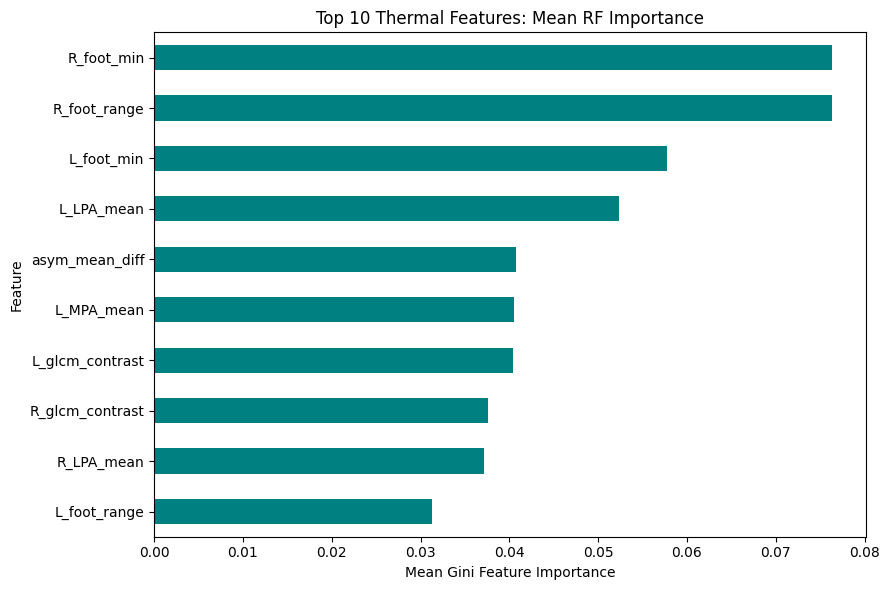

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Importance plot saved to: /content/drive/MyDrive/diabetes_model_outputs/feature_importance.png
Importance table saved to: /content/drive/MyDrive/diabetes_model_outputs/feature_importance_summary.csv

PHYSIOLOGICAL COMPARISON
-----------------------------------------------------------------

Mean temperature of both feet (°C)
  Control: 26.72 ± 1.61
  DM:      29.73 ± 2.86
  Difference (DM - Control): 3.01 °C

Absolute left-right mean temperature difference (°C)
  Control: 0.31 ± 0.21
  DM:      0.71 ± 0.77
  Difference (DM - Control): 0.39 °C

Absolute left-right maximum temperature difference (°C)
  Control: 0.42 ± 0.43
  DM:      0.83 ± 0.81
  Difference (DM - Control): 0.41 °C

Note: These are descriptive group comparisons,
not tests of statistical significance or causation.


In [15]:

# CELL 12: Feature Importance & Physiological Alignment

# --------------------------------------------------
# 1. Prepare subject-level data
# --------------------------------------------------

df_eval = df_features.copy().reset_index(drop=True)

assert df_eval["subject_id"].is_unique, (
    "Each subject must have one row. Check Cell 7."
)

y = df_eval["label"].astype(int).to_numpy()
groups = df_eval["subject_id"].astype(str).to_numpy()

thermal_cols = [
    c for c in df_eval.columns
    if c not in ["subject_id", "label", "age", "gender_code"]
]

X = (
    df_eval[thermal_cols]
    .apply(pd.to_numeric, errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
)

# Remove columns entirely missing in the dataset
X = X.loc[:, X.notna().any(axis=0)]
thermal_cols = X.columns.tolist()

# --------------------------------------------------
# 2. Feature importance across patient-level folds
# --------------------------------------------------

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

importance_by_fold = []

for fold, (train_idx, test_idx) in enumerate(
    cv.split(X, y, groups), start=1
):
    X_train = X.iloc[train_idx].copy()
    y_train = y[train_idx]

    # Keep features that have data in this training fold
    usable_cols = X_train.columns[
        X_train.notna().any(axis=0)
    ].tolist()

    X_train = X_train[usable_cols]

    # Impute using training-fold medians only
    medians = X_train.median()
    X_train = X_train.fillna(medians)

    if X_train.shape[1] == 0:
        print(f"Skipping fold {fold}: no usable features.")
        continue

    clf_rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=4,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    clf_rf.fit(X_train, y_train)

    # Preserve all feature names, including those unavailable
    # in this fold, so the results can be aggregated.
    fold_importance = pd.Series(
        0.0,
        index=thermal_cols,
        dtype=float
    )

    fold_importance.loc[usable_cols] = clf_rf.feature_importances_
    importance_by_fold.append(fold_importance)

if len(importance_by_fold) == 0:
    raise ValueError("No folds produced feature importance results.")

importance_df = pd.DataFrame(importance_by_fold)

feat_imp = importance_df.mean(axis=0).sort_values(ascending=False)

importance_summary = pd.DataFrame({
    "Feature": feat_imp.index,
    "Mean Importance": feat_imp.values,
    "Std Across Folds": [
        importance_df[col].std(ddof=1)
        if len(importance_df) > 1 else 0.0
        for col in feat_imp.index
    ],
    "Top 10 Frequency": [
        sum(col in importance_df.iloc[i].nlargest(
            min(10, len(thermal_cols))
        ).index for i in range(len(importance_df)))
        for col in feat_imp.index
    ]
})

print("TOP 10 THERMAL FEATURES")
display(importance_summary.head(10).round(4))

# --------------------------------------------------
# 3. Plot mean feature importance across folds
# --------------------------------------------------

top10 = feat_imp.head(10).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
top10.plot(kind="barh", color="teal")

plt.title("Top 10 Thermal Features: Mean RF Importance")
plt.xlabel("Mean Gini Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()

importance_path = OUTPUT_DIR / "feature_importance.png"
plt.savefig(importance_path, dpi=150, bbox_inches="tight")
plt.show()

# Save the complete feature importance summary
importance_csv = OUTPUT_DIR / "feature_importance_summary.csv"
importance_summary.to_csv(importance_csv, index=False)

print(f"Importance plot saved to: {importance_path}")
print(f"Importance table saved to: {importance_csv}")

# --------------------------------------------------
# 4. Physiological comparison between groups
# --------------------------------------------------

print("\nPHYSIOLOGICAL COMPARISON")
print("-" * 65)

for feature, description, unit in [
    ("both_feet_mean", "Mean temperature of both feet", "°C"),
    ("asym_mean_diff", "Absolute left-right mean temperature difference", "°C"),
    ("asym_max_diff", "Absolute left-right maximum temperature difference", "°C")
]:
    if feature not in df_eval.columns:
        print(f"{description}: feature not found.")
        continue

    control_values = pd.to_numeric(
        df_eval.loc[df_eval["label"] == 0, feature],
        errors="coerce"
    ).dropna()

    dm_values = pd.to_numeric(
        df_eval.loc[df_eval["label"] == 1, feature],
        errors="coerce"
    ).dropna()

    print(f"\n{description} ({unit})")

    if len(control_values) and len(dm_values):
        print(
            f"  Control: {control_values.mean():.2f} "
            f"± {control_values.std():.2f}"
        )
        print(
            f"  DM:      {dm_values.mean():.2f} "
            f"± {dm_values.std():.2f}"
        )
        print(
            f"  Difference (DM - Control): "
            f"{dm_values.mean() - control_values.mean():.2f} {unit}"
        )
    else:
        print("  Insufficient valid observations.")

print("\nNote: These are descriptive group comparisons,")
print("not tests of statistical significance or causation.")

In [16]:

# CELL 13: Stress Testing (Thermal Drift & Noise)

# --------------------------------------------------
# 1. Prepare subject-level thermal features
# --------------------------------------------------

df_eval = df_features.copy().reset_index(drop=True)

assert df_eval["subject_id"].is_unique, (
    "Expected one row per subject. Check Cell 7."
)

y = df_eval["label"].astype(int).to_numpy()
groups = df_eval["subject_id"].astype(str).to_numpy()

thermal_cols = [
    c for c in df_eval.columns
    if c not in ["subject_id", "label", "age", "gender_code"]
]

X = (
    df_eval[thermal_cols]
    .apply(pd.to_numeric, errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
)

# Remove features that are entirely missing
X = X.loc[:, X.notna().any(axis=0)]

# Absolute-temperature features:
# Means, minima, maxima, medians, and percentiles.
# Exclude asymmetry and range features because a uniform
# temperature shift should not change these quantities.
absolute_suffixes = (
    "_mean", "_min", "_max", "_median", "_p10", "_p90"
)

temp_cols = [
    c for c in X.columns
    if not c.startswith("asym_")
    and c.endswith(absolute_suffixes)
]

if not temp_cols:
    raise ValueError("No absolute-temperature features were found.")

print(f"Subjects: {len(X)}")
print(f"Thermal features: {X.shape[1]}")
print(f"Absolute-temperature features perturbed: {len(temp_cols)}")

# --------------------------------------------------
# 2. Patient-level cross-validation
# --------------------------------------------------

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

base_oof = np.full(len(y), np.nan)
shift_oof = np.full(len(y), np.nan)

# Repeat noise perturbations to reduce dependence on one
# random noise realization.
N_NOISE_REPEATS = 20
noise_oof = np.full((N_NOISE_REPEATS, len(y)), np.nan)

rng = np.random.default_rng(42)

for fold, (train_idx, test_idx) in enumerate(
    cv.split(X, y, groups), start=1
):

    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()
    y_train = y[train_idx]

    # Use only features with data in this training fold
    usable_cols = X_train.columns[
        X_train.notna().any(axis=0)
    ].tolist()

    if not usable_cols:
        raise ValueError(f"No usable features in fold {fold}.")

    X_train = X_train[usable_cols]
    X_test = X_test[usable_cols]

    # Fit imputation values using training data only
    train_medians = X_train.median()

    X_train = X_train.fillna(train_medians)
    X_test = X_test.fillna(train_medians)

    # Fit scaling using training data only
    scaler = RobustScaler()
    X_train_sc = scaler.fit_transform(X_train)

    clf = LogisticRegression(
        class_weight="balanced",
        C=0.5,
        max_iter=3000,
        random_state=42
    )
    clf.fit(X_train_sc, y_train)

    # A. Baseline predictions
    X_test_sc = scaler.transform(X_test)
    base_oof[test_idx] = clf.predict_proba(X_test_sc)[:, 1]

    # Identify temperature columns available in this fold
    fold_temp_cols = [
        c for c in temp_cols if c in usable_cols
    ]

    # B. Temperature drift: +0.3 degrees C
    X_shift = X_test.copy()
    X_shift.loc[:, fold_temp_cols] += 0.3

    X_shift_sc = scaler.transform(X_shift)
    shift_oof[test_idx] = clf.predict_proba(X_shift_sc)[:, 1]

    # C. Random sensor noise: sigma = 0.1 degrees C
    for repeat in range(N_NOISE_REPEATS):
        X_noise = X_test.copy()

        noise = rng.normal(
            loc=0.0,
            scale=0.1,
            size=(len(X_noise), len(fold_temp_cols))
        )

        X_noise.loc[:, fold_temp_cols] = (
            X_noise[fold_temp_cols].to_numpy() + noise
        )

        X_noise_sc = scaler.transform(X_noise)

        noise_oof[repeat, test_idx] = (
            clf.predict_proba(X_noise_sc)[:, 1]
        )

# --------------------------------------------------
# 3. Calculate out-of-fold AUCs
# --------------------------------------------------

if (
    np.isnan(base_oof).any()
    or np.isnan(shift_oof).any()
    or np.isnan(noise_oof).any()
):
    raise ValueError("Some subjects are missing predictions.")

base_auc = roc_auc_score(y, base_oof)
auc_shift = roc_auc_score(y, shift_oof)

noise_aucs = np.array([
    roc_auc_score(y, noise_oof[i])
    for i in range(N_NOISE_REPEATS)
])

mean_noise_auc = noise_aucs.mean()
std_noise_auc = noise_aucs.std(ddof=1)

print("\n" + "=" * 60)
print("STRESS-TEST RESULTS: PATIENT-LEVEL OUT-OF-FOLD AUC")
print("=" * 60)

print(f"Baseline AUC:              {base_auc:.3f}")
print(
    f"Temperature drift (+0.3 C): {auc_shift:.3f} "
    f"(Delta = {auc_shift - base_auc:+.3f})"
)
print(
    f"Gaussian noise (sigma=0.1 C): "
    f"{mean_noise_auc:.3f} +/- {std_noise_auc:.3f}"
)
print(
    f"Mean noise AUC change:     "
    f"{mean_noise_auc - base_auc:+.3f}"
)

print("=" * 60)
print("Positive delta = AUC increased; negative delta = AUC decreased.")
print("Noise result is mean +/- SD over repeated noise realizations.")


Subjects: 167
Thermal features: 36
Absolute-temperature features perturbed: 22


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:451: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  opt_res = optimize.minimize(
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future ver


STRESS-TEST RESULTS: PATIENT-LEVEL OUT-OF-FOLD AUC
Baseline AUC:              0.945
Temperature drift (+0.3 C): 0.946 (Delta = +0.001)
Gaussian noise (sigma=0.1 C): 0.946 +/- 0.000
Mean noise AUC change:     +0.000
Positive delta = AUC increased; negative delta = AUC decreased.
Noise result is mean +/- SD over repeated noise realizations.


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [17]:

# CELL 14: Six-Channel CNN with Patient-Level 5-Fold CV

from torch.utils.data import TensorDataset
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    roc_auc_score,
    balanced_accuracy_score,
    confusion_matrix
)

# --------------------------------------------------
# 1. Prepare the thermogram inputs
# --------------------------------------------------

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

df_cnn = master_df.reset_index(drop=True).copy()

assert df_cnn["subject_id"].is_unique, (
    "Expected one row per subject."
)

image_samples = []
labels = []
subject_groups = []

print("Preparing six-channel thermograms...")

for _, row in df_cnn.iterrows():

    mat_l = pd.read_csv(
        row["left_csv"], header=None
    ).values.astype(np.float32)

    mat_r = pd.read_csv(
        row["right_csv"], header=None
    ).values.astype(np.float32)

    # Geometry-standardized temperature and z-score images
    temp_l, z_l = standardize_foot_geometry(
        mat_l, is_left=True
    )

    temp_r, z_r = standardize_foot_geometry(
        mat_r, is_left=False
    )

    # Masks identify valid foot pixels
    mask_l = temp_l > 0
    mask_r = temp_r > 0

    # Keep absolute temperature information.
    # Center at 30 C and scale by 10 for numerical stability.
    abs_l = np.where(
        mask_l, (temp_l - 30.0) / 10.0, 0.0
    ).astype(np.float32)

    abs_r = np.where(
        mask_r, (temp_r - 30.0) / 10.0, 0.0
    ).astype(np.float32)

    # Six channels:
    # 0 left absolute temperature
    # 1 right absolute temperature
    # 2 left relative temperature (z-score)
    # 3 right relative temperature (z-score)
    # 4 left foot mask
    # 5 right foot mask
    image = np.stack([
        abs_l,
        abs_r,
        z_l,
        z_r,
        mask_l.astype(np.float32),
        mask_r.astype(np.float32)
    ], axis=0)

    image_samples.append(image)
    labels.append(int(row["label"]))
    subject_groups.append(str(row["subject_id"]))

X_images = np.stack(image_samples).astype(np.float32)
y_cnn = np.asarray(labels, dtype=np.int64)
groups_cnn = np.asarray(subject_groups)

print("Image tensor shape:", X_images.shape)
print("Subjects:", len(y_cnn))
print("Control:", int((y_cnn == 0).sum()))
print("DM:", int((y_cnn == 1).sum()))

# --------------------------------------------------
# 2. Define a small CNN with six input channels
# --------------------------------------------------

class SixChannelThermalCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(6, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.35),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


# --------------------------------------------------
# 3. Five-fold patient-level cross-validation
# --------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

oof_probs = np.full(len(y_cnn), np.nan)
fold_aucs = []

EPOCHS = 15
BATCH_SIZE = 16

for fold, (train_idx, test_idx) in enumerate(
    cv.split(X_images, y_cnn, groups_cnn), start=1
):

    print(f"\n========== Fold {fold}/5 ==========")

    # Reset random state for reproducibility
    torch.manual_seed(SEED + fold)

    X_train = torch.from_numpy(
        X_images[train_idx]
    )
    y_train = torch.from_numpy(
        y_cnn[train_idx]
    )

    X_test = torch.from_numpy(
        X_images[test_idx]
    )

    train_counts = np.bincount(
        y_cnn[train_idx], minlength=2
    )

    if np.any(train_counts == 0):
        raise ValueError(
            f"Fold {fold} training set is missing a class."
        )

    # Calculate class weights from training subjects only
    weights = len(train_idx) / (2.0 * train_counts)

    criterion = nn.CrossEntropyLoss(
        weight=torch.tensor(
            weights, dtype=torch.float32, device=device
        )
    )

    train_dataset = TensorDataset(X_train, y_train)

    generator = torch.Generator()
    generator.manual_seed(SEED + fold)

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=generator
    )

    model = SixChannelThermalCNN().to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=0.0005,
        weight_decay=0.001
    )

    # Fixed training schedule: do not tune on the held-out fold
    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0.0

        for imgs, targets in train_loader:
            imgs = imgs.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()

            logits = model(imgs)
            loss = criterion(logits, targets)

            loss.backward()
            optimizer.step()

            total_loss += loss.item() * imgs.size(0)

        avg_loss = total_loss / len(train_idx)

        if epoch == 0 or (epoch + 1) % 5 == 0:
            print(
                f"Epoch {epoch + 1}/{EPOCHS}, "
                f"Loss: {avg_loss:.4f}"
            )

    # Predict only on subjects held out from this fold
    model.eval()

    with torch.no_grad():
        test_logits = model(X_test.to(device))
        probabilities = torch.softmax(
            test_logits, dim=1
        )[:, 1].cpu().numpy()

    oof_probs[test_idx] = probabilities

    fold_auc = roc_auc_score(
        y_cnn[test_idx], probabilities
    )
    fold_aucs.append(fold_auc)

    print(
        f"Fold {fold} AUC: {fold_auc:.3f} "
        f"(test subjects: {len(test_idx)})"
    )

# --------------------------------------------------
# 4. Aggregate out-of-fold predictions
# --------------------------------------------------

if np.isnan(oof_probs).any():
    raise ValueError(
        "Some subjects did not receive out-of-fold predictions."
    )

overall_auc = roc_auc_score(y_cnn, oof_probs)

# 0.50 is a reporting threshold, not a calibrated clinical threshold
predictions = (oof_probs >= 0.50).astype(int)

bacc = balanced_accuracy_score(
    y_cnn, predictions
)

tn, fp, fn, tp = confusion_matrix(
    y_cnn, predictions, labels=[0, 1]
).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
specificity = tn / (tn + fp) if (tn + fp) else 0.0

print("\n" + "=" * 55)
print("SIX-CHANNEL CNN: OUT-OF-FOLD RESULTS")
print("=" * 55)

print(f"Mean fold AUC:       {np.mean(fold_aucs):.3f}")
print(f"Fold AUC SD:         {np.std(fold_aucs, ddof=1):.3f}")
print(f"Overall OOF AUC:     {overall_auc:.3f}")
print(f"Balanced accuracy:   {bacc:.3f}")
print(f"Sensitivity:         {sensitivity:.3f}")
print(f"Specificity:         {specificity:.3f}")

print("=" * 55)
print("Device:", device)
print("Each subject is evaluated only when held out from training.")

Preparing six-channel thermograms...


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Image tensor shape: (167, 6, 128, 64)
Subjects: 167
Control: 45
DM: 122

========== Fold 1/5 ==========


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Epoch 1/15, Loss: 0.5898
Epoch 5/15, Loss: 0.4287
Epoch 10/15, Loss: 0.3767
Epoch 15/15, Loss: 0.3358
Fold 1 AUC: 0.884 (test subjects: 34)

========== Fold 2/5 ==========


...

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Epoch 1/15, Loss: 0.6219
Epoch 5/15, Loss: 0.4477
Epoch 10/15, Loss: 0.3676
Epoch 15/15, Loss: 0.3444
Fold 4 AUC: 0.921 (test subjects: 33)

========== Fold 5/5 ==========


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Epoch 1/15, Loss: 0.5941
Epoch 5/15, Loss: 0.4449
Epoch 10/15, Loss: 0.3633
Epoch 15/15, Loss: 0.3455
Fold 5 AUC: 0.954 (test subjects: 33)

SIX-CHANNEL CNN: OUT-OF-FOLD RESULTS
Mean fold AUC:       0.935
Fold AUC SD:         0.042
Overall OOF AUC:     0.924
Balanced accuracy:   0.851
Sensitivity:         0.746
Specificity:         0.956
Device: cpu
Each subject is evaluated only when held out from training.


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# CELL 20 (FIXED): Matched-Pair Concordance Check
# Self-contained: builds the age/gender-matched pairs and the out-of-fold
# probabilities that the original cell expected to already exist.
# Requires: df_features (Cell 7) and the imports from Cell 1.

from scipy.optimize import linear_sum_assignment

# --------------------------------------------------
# 1. Out-of-fold probabilities for every subject
# --------------------------------------------------
df_eval = df_features.copy().reset_index(drop=True)
assert df_eval["subject_id"].is_unique

y_all = df_eval["label"].astype(int).to_numpy()
groups_all = df_eval["subject_id"].astype(str).to_numpy()

thermal_cols = [c for c in df_eval.columns
                if c not in ["subject_id", "label", "age", "gender_code"]]
X_all = (df_eval[thermal_cols].apply(pd.to_numeric, errors="coerce")
         .replace([np.inf, -np.inf], np.nan))
X_all = X_all.loc[:, X_all.notna().any(axis=0)]

oof_probabilities = np.full(len(y_all), np.nan)
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

for tr, te in cv.split(X_all, y_all, groups_all):
    Xtr, Xte = X_all.iloc[tr], X_all.iloc[te]
    cols = Xtr.columns[Xtr.notna().any(axis=0)].tolist()
    med = Xtr[cols].median()
    Xtr, Xte = Xtr[cols].fillna(med), Xte[cols].fillna(med)
    sc = RobustScaler().fit(Xtr)
    clf = LogisticRegression(class_weight="balanced", C=0.5,
                             max_iter=3000, random_state=42)
    clf.fit(sc.transform(Xtr), y_all[tr])
    oof_probabilities[te] = clf.predict_proba(sc.transform(Xte))[:, 1]

assert not np.isnan(oof_probabilities).any()

# --------------------------------------------------
# 2. One-to-one Control <-> DM matching (age, then gender)
# --------------------------------------------------
AGE_CALIPER = 5.0  # years; pairs further apart are discarded

ctrl = df_eval.index[(y_all == 0) & df_eval["age"].notna()].to_numpy()
dm = df_eval.index[(y_all == 1) & df_eval["age"].notna()].to_numpy()

age = pd.to_numeric(df_eval["age"], errors="coerce").to_numpy()
gen = df_eval["gender_code"].to_numpy()

cost = np.abs(age[dm][:, None] - age[ctrl][None, :])
gender_mismatch = ~((gen[dm][:, None] == gen[ctrl][None, :]))  # NaN -> mismatch
cost = cost + 100.0 * gender_mismatch          # strongly prefer same gender

r, c = linear_sum_assignment(cost)             # optimal assignment

pairs = []
for i, j in zip(r, c):
    d_idx, c_idx = dm[i], ctrl[j]
    if abs(age[d_idx] - age[c_idx]) <= AGE_CALIPER:
        pairs.append((d_idx, c_idx))

if not pairs:
    raise ValueError("No matched pairs found; widen AGE_CALIPER.")

match_idx, y_match, pair_ids = [], [], []
for pid, (d_idx, c_idx) in enumerate(pairs):
    match_idx += [c_idx, d_idx]
    y_match += [0, 1]
    pair_ids += [pid, pid]

match_idx = np.array(match_idx)
y_match = np.array(y_match)
pair_ids = np.array(pair_ids)
oof_match = oof_probabilities[match_idx]   # probabilities for matched subjects

print(f"Matched pairs: {len(pairs)} "
      f"(mean age gap {np.mean([abs(age[d]-age[c]) for d,c in pairs]):.1f} y, "
      f"same gender: {sum(gen[d]==gen[c] for d,c in pairs)}/{len(pairs)})")

# --------------------------------------------------
# 3. Matched-pair concordance
# --------------------------------------------------
pair_results = []
for pid in np.unique(pair_ids):
    idx = np.where(pair_ids == pid)[0]
    control_idx = idx[y_match[idx] == 0]
    dm_idx = idx[y_match[idx] == 1]
    assert len(control_idx) == 1 and len(dm_idx) == 1

    p_control = oof_match[control_idx[0]]
    p_dm = oof_match[dm_idx[0]]

    outcome = 1.0 if p_dm > p_control else (0.5 if p_dm == p_control else 0.0)
    pair_results.append({
        "pair_id": pid,
        "control_subject": df_eval.loc[match_idx[control_idx[0]], "subject_id"],
        "dm_subject": df_eval.loc[match_idx[dm_idx[0]], "subject_id"],
        "control_probability": p_control,
        "dm_probability": p_dm,
        "correct_pair_order": outcome,
    })

pair_df = pd.DataFrame(pair_results)
pair_concordance = pair_df["correct_pair_order"].mean()

print("=== MATCHED-PAIR CONCORDANCE ===")
print("Matched pairs:", len(pair_df))
print(f"Pair concordance: {pair_concordance:.3f}")
print("Pairs correctly ordered (including half-credit ties):",
      pair_df["correct_pair_order"].sum(), "out of", len(pair_df))
display(pair_df.round(3))